In [1]:
from tagger.data.tools import load_data, to_ML

data_config = {
    "data_path": "./training_data/",
    "percentage": 100,
    "validation_split": 0,
    "n_particles": 32,
}
path = data_config["data_path"]
data, class_labels, input_vars, extra_vars = load_data(
            path=path,
            percentage=data_config.get("percentage", None),
            fields=data_config.get("fields", None),
        )  # returns full data with all existing labels
        # Make into ML-like data for training
X, y, X_val, y_val = to_ML(
    data,
    all_labels=class_labels,
    val_ratio=data_config.get("validation_split", None),
    target_labels=data_config.get("target_labels", None),
    n_particles=data_config.get("n_particles", None),
    shuffle_constits=data_config.get("shuffle_constits", False))
del data

Loading data from:  ./training_data/
Loading percentage:  100
Class distribution after filtering: [1.158900e+04 5.545400e+04 1.286940e+05 8.487000e+03 1.636800e+04
 4.272000e+03 1.438100e+04 1.240200e+05 2.020000e+03 1.686140e+05
 1.733680e+05 8.402000e+03 3.328900e+04 1.453730e+05 3.483300e+04
 2.545962e+06 1.862130e+05 1.999000e+03 4.457600e+04 2.276700e+04
 7.112000e+04 2.817500e+04 1.171500e+04 5.500000e+01 1.668850e+05
 4.136000e+03 8.632000e+03 1.112100e+05 2.781300e+04] 


[2.545962e+06 1.862130e+05 1.733680e+05 1.686140e+05 1.668850e+05
 1.453730e+05 1.286940e+05 1.240200e+05 1.112100e+05 7.112000e+04
 5.545400e+04 4.457600e+04 3.483300e+04 3.328900e+04 2.817500e+04
 2.781300e+04 2.276700e+04 1.636800e+04 1.438100e+04 1.171500e+04
 1.158900e+04 8.632000e+03 8.487000e+03 8.402000e+03 4.272000e+03
 4.136000e+03 2.020000e+03 1.999000e+03 5.500000e+01]


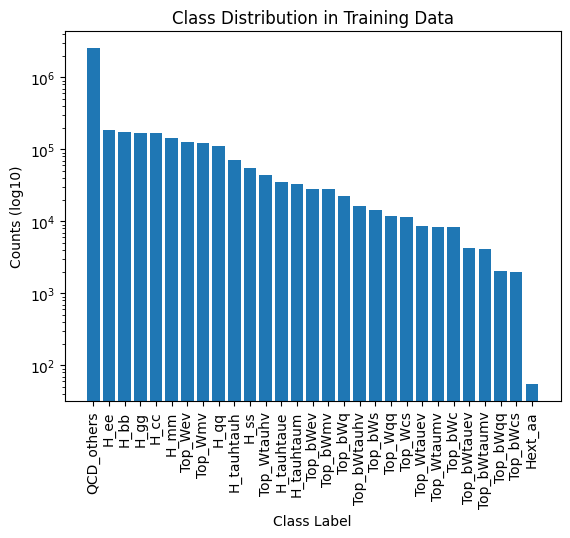

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# plot class distribution
counts = np.sum(y, axis=0)
sorted_indices = np.argsort(counts)[::-1]
counts = counts[sorted_indices]
unique = np.arange(len(counts))
labels = [k for k in class_labels.keys()]
labels = [labels[i] for i in sorted_indices]
print(counts)
plt.bar(unique, counts)
plt.xlabel("Class Label")
plt.ylabel("Counts (log10)")
plt.xticks(unique, labels, rotation=90)
plt.yscale("log")
#plt.xticks(unique, [k for k in class_labels.keys()])
plt.title("Class Distribution in Training Data")
plt.show()